# CS6405 – Data Mining
## In-Class Programming Assessment (Dry Run)

**Duration:** 1.5 hours  
**Open book – no GenAI tools permitted. Neither GenAI Functionalities of Colab**  
**Submit:** this notebook file

---

### Student details

**Name:** Max Warriner  
**Student ID:** 126104460  
**Lab machine number:**

---

## Context

You are given a dataset collected from wearable sensors (IMU + EMG) to estimate **fatigue (Borg score)** during physical exercises.

Each row corresponds to one repetition and includes:

- `Subject`
- `Repetition`
- `Borg` (target: 6–20)
- sensor-derived features

Your goal is to design and implement a **machine learning solution that could realistically be deployed**.


In [19]:
# Data load
import pandas as pd

file_id = '1DP3G49DWVUaRBkn7wssPi6CfY1pTmTQP'
url = f'https://drive.google.com/uc?id={file_id}'

df = pd.read_csv(url)

df.head()

,Subject,Repetition,X_Shoulder_acc_MPSD,X_Shoulder_acc_Freq_MPSD,X_Shoulder_acc_Power_Dominant_Band,X_Shoulder_acc_Ratio_Dominant_Band,X_Shoulder_acc_Total_LowFreq_Power,X_Shoulder_acc_Total_HighFreq_Power,X_Shoulder_acc_LowHigh_FreqRatio,X_Shoulder_acc_Total_Power,...,Magnitude_Palm_gyr_rtVar_Max,Magnitude_Palm_gyr_rtVar_Min,Magnitude_Palm_gyr_rtVar_Range,Magnitude_Palm_gyr_rtVar_RMS,Magnitude_Palm_gyr_rtVar_Energy,Magnitude_Palm_gyr_rtVar_IQR,Magnitude_Palm_gyr_rtVar_Skewness,Magnitude_Palm_gyr_rtVar_Kurtosis,RepetitionDuration_Palm_gyr_rtVar,Borg
0,1,1,2068.313,0.000,0.000,0.000,2318.602,154.645,14.993,2473.247,...,0.153,-0.170,0.324,0.051,0.797,0.059,-0.465,1.233,3.10,9.355
1,1,2,150.884,0.699,150.884,0.183,503.764,322.154,1.564,825.919,...,0.148,-0.196,0.344,0.056,0.892,0.064,-0.184,0.645,2.86,9.653
2,1,3,342.205,0.000,0.000,0.000,862.122,197.057,4.375,1059.179,...,0.104,-0.107,0.211,0.040,0.479,0.051,0.007,0.133,2.99,9.946
3,1,4,574.134,0.000,0.000,0.000,1007.744,195.604,5.152,1203.347,...,0.149,-0.177,0.325,0.056,0.908,0.069,-0.240,0.136,2.91,10.240
4,1,5,146.332,1.993,146.332,0.123,826.328,364.276,2.268,1190.603,...,0.160,-0.197,0.357,0.058,1.018,0.069,-0.144,0.439,3.01,10.536


<Axes: >

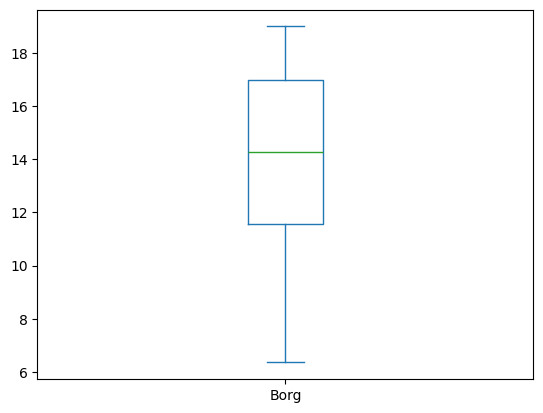

In [15]:
# Label or target variable
df['Borg'].plot.box()

## Task

Develop a regression model to predict **Borg score**.  
Your notebook should clearly show your reasoning, implementation, and results.

---

## 1. Data Preparation and Design Choices

Tasks:
- Load and inspect the dataset
- Define features and target
- Split the data into training and test sets

You may choose how to:
- use a subset of the data
- prepare the features

In a short comment:
- Explain **one preprocessing choice** you made
- Explain **one potential source of data leakage** in this dataset


In [26]:
# Write your code for Part 1 here

y = df['Borg']
X = df.drop(columns=['Subject', 'Repetition', 'Borg'])

from sklearn.decomposition import PCA

pca = PCA(n_components=100)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pca.fit(X_train)

X_train = pca.transform(X_train)
X_test = pca.transform(X_test)



**Short comment for Part 1:**

I PCA transformed the data into n = 100 components to reduce dimensionality of the dataset. A source of leakage in the dataset is that there are repeated measures that could mean a single person is included in the test and train set and those measurements would be dependent on each other.

---

## 2. Model Training

Tasks:
- Train at least **one regression model** of your choice
- Use a reasonable parameter grid

In a short comment:
- Explain an advantage of that model


In [33]:
# Write your code for Part 2 here.

from sklearn import neighbors
from sklearn.model_selection import GridSearchCV

knn = neighbors.KNeighborsRegressor()
parameters = {'n_neighbors':[1,2,3,5,10,20], 'weights':("uniform", "distance")}

clf = GridSearchCV(knn, parameters)
clf.fit(X_train, y_train)

print(clf.best_params_)

knn = neighbors.KNeighborsRegressor(n_neighbors=5, weights='distance')
knn.fit(X_train, y_train)


{'n_neighbors': 5, 'weights': 'distance'}


KNeighborsRegressor(weights='distance')

**Short comment for Part 2:**

There's no retraining time when predicting a new data point for KNN. It always compares the distances against every point instead of training a set model.

---

## 3. Evaluation

Tasks:
- Evaluate your model using **at least two metrics**

In a short comment:
- Interpret the results (are they good or not?)
- Are they better than a baseline classifier?


In [44]:
# Write your code for Part 3 here

predictions = knn.predict(X_test)

#Mean absolute error
model_MAE = abs(predictions - y_test).mean()
print("Model Mean Absolute Error =", model_MAE)
baseline_MAE = abs(y_train.mean() - y_test).mean()
print("Baseline Mean Absolute Error =", baseline_MAE)

print()

#Root Mean Square Error
import math
model_RMSE = math.sqrt(((predictions - y_test)**2).mean())
print("Model Root Mean Square Error =", model_RMSE)
baseline_RMSE = math.sqrt(((y_train.mean() - y_test)**2).mean())
print("Baseline Root Mean Square Error =", baseline_RMSE)


Model Mean Absolute Error = 2.028497725368548
Baseline Mean Absolute Error = 2.798249063322418

Model Root Mean Square Error = 2.592092167483731
Baseline Root Mean Square Error = 3.2476553342733325


**Short comment for Part 3:**

The model does perform better than the baseline in MAE and RMSE. However, a MAE and RMSE around 2-2.5 is still quite high when compared to the spread of 'Borg' in the boxplot.

---

## 4. Model Evaluation on Unseen Instances

Tasks:
- Test your model in a new unseen **test set**.

In a short comment:
- Explain if your model overfitted the training set


In [46]:
# Data load
df_test = pd.read_csv('https://raw.githubusercontent.com/andvise/DM_Assignment_2425/refs/heads/main/test_data.csv')

df_test




,Subject,Repetition,X_Shoulder_acc_MPSD,X_Shoulder_acc_Freq_MPSD,X_Shoulder_acc_Power_Dominant_Band,X_Shoulder_acc_Ratio_Dominant_Band,X_Shoulder_acc_Total_LowFreq_Power,X_Shoulder_acc_Total_HighFreq_Power,X_Shoulder_acc_LowHigh_FreqRatio,X_Shoulder_acc_Total_Power,...,Magnitude_Palm_gyr_rtVar_Max,Magnitude_Palm_gyr_rtVar_Min,Magnitude_Palm_gyr_rtVar_Range,Magnitude_Palm_gyr_rtVar_RMS,Magnitude_Palm_gyr_rtVar_Energy,Magnitude_Palm_gyr_rtVar_IQR,Magnitude_Palm_gyr_rtVar_Skewness,Magnitude_Palm_gyr_rtVar_Kurtosis,RepetitionDuration_Palm_gyr_rtVar,Borg
0,25,6,807.432,10.561,1065.986,0.256,1193.680,2975.000,0.401,4168.680,...,0.218,-0.384,0.601,0.086,2.213,0.082,-1.260,4.397,3.03,12.673
1,10,27,8592.096,0.000,0.000,0.000,9994.720,8852.342,1.129,18847.062,...,0.807,-0.713,1.520,0.206,12.147,0.246,-0.019,1.286,2.86,18.178
2,26,2,9889.781,0.000,0.000,0.000,10861.744,899.593,12.074,11761.337,...,0.273,-0.370,0.644,0.113,3.525,0.146,-0.224,0.106,2.75,8.606
3,21,9,3823.497,0.000,0.000,0.000,5272.307,2284.320,2.308,7556.627,...,0.236,-0.328,0.565,0.084,2.020,0.100,-0.437,1.140,2.87,13.654
4,10,44,7446.974,0.000,0.000,0.000,8912.057,11519.947,0.774,20432.004,...,0.668,-0.639,1.307,0.219,13.589,0.324,-0.036,-0.233,2.85,19.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
578,12,8,265.573,0.319,265.573,0.116,617.691,1678.106,0.368,2295.797,...,0.169,-0.185,0.354,0.052,0.829,0.063,-0.258,0.646,3.13,16.859
579,6,4,316.069,0.326,316.069,0.193,772.373,864.809,0.893,1637.182,...,0.404,-0.234,0.638,0.087,2.296,0.083,0.729,2.452,3.07,11.503
580,11,12,244.083,10.030,468.726,0.184,932.956,1620.065,0.576,2553.020,...,0.278,-0.273,0.550,0.084,2.289,0.096,-0.107,0.889,3.29,13.000
581,14,4,8763.690,0.331,8763.690,0.837,9783.721,681.556,14.355,10465.276,...,0.104,-0.143,0.247,0.045,0.606,0.060,-0.295,-0.047,3.02,13.454


In [50]:
# Write your code for Part 4 here

y_test_new = df_test['Borg']
X_test_new = df_test.drop(columns=['Subject', 'Repetition', 'Borg'])

X_test_new = pca.transform(X_test_new)

predictions_new = knn.predict(X_test_new)

#Mean absolute error
model_MAE = abs(predictions_new - y_test_new).mean()
print("New Model Mean Absolute Error =", model_MAE)
baseline_MAE = abs(y_train.mean() - y_test_new).mean()
print("Baseline Mean Absolute Error =", baseline_MAE)

print()

#Root Mean Square Error
import math
model_RMSE = math.sqrt(((predictions_new - y_test_new)**2).mean())
print("New model Root Mean Square Error =", model_RMSE)
baseline_RMSE = math.sqrt(((y_train.mean() - y_test_new)**2).mean())
print("Baseline Root Mean Square Error =", baseline_RMSE)





New Model Mean Absolute Error = 1.9032702826101269
Baseline Mean Absolute Error = 2.7919712480915315

New model Root Mean Square Error = 2.510786753425436
Baseline Root Mean Square Error = 3.2386435240446256


**Short comment for Part 4:**

It seems like the model is not overfit. The model actually performs better on the unseen data with a lower MAE and RMSE.

---

# Final checklist before submission

- [ ] I used my **student Google account**
- [ ] All work is contained in this notebookghts
- [ ] I did **not** use Generative AI
- [ ] I submitted it on Canvas


In [8]:
# Rerun with pipeline
import pandas as pd

file_id = '1DP3G49DWVUaRBkn7wssPi6CfY1pTmTQP'
url = f'https://drive.google.com/uc?id={file_id}'

df = pd.read_csv(url)

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsRegressor

y = df['Borg']
X = df.drop(columns=['Subject', 'Repetition', 'Borg'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca",    PCA()),
    ("knn",    KNeighborsRegressor()),
])


param_grid = {
    "pca__n_components": [50, 100],
    "knn__n_neighbors":  [1, 3, 5,],
    "knn__weights":      ["uniform", "distance"],
}


grid_search = GridSearchCV(
    estimator  = pipeline,
    param_grid = param_grid,
    cv         = 10,
    scoring    = "neg_mean_squared_error",
    verbose    = 1,
    refit      = True,            # refit best model on full training set automatically
)

grid_search.fit(X_train, y_train)


Fitting 10 folds for each of 12 candidates, totalling 120 fits


GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('pca', PCA()),
                                       ('knn', KNeighborsRegressor())]),
             param_grid={'knn__n_neighbors': [1, 3, 5],
                         'knn__weights': ['uniform', 'distance'],
                         'pca__n_components': [50, 100]},
             scoring='neg_mean_squared_error', verbose=1)

In [10]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'knn__n_neighbors': 3, 'knn__weights': 'distance', 'pca__n_components': 100}
-5.207576727313252


In [12]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

In [14]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

print(np.sqrt(mean_squared_error(y_test, y_pred)))

2.2594458078830097
